In [2]:
#@title 1. Ekstrak Dataset & Persiapan
import zipfile
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Lokasi file zip (sesuaikan jika namanya berbeda, misal '/content/archive.zip' di Colab)
zip_path = 'archive.zip'
extract_to = 'dataset_beras'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Ekstraksi selesai! Data disimpan di folder: {extract_to}")
else:
    print(f"❌ File {zip_path} tidak ditemukan! Pastikan file sudah di-upload.")

# List kategori berdasarkan folder yang kita temukan sebelumnya
kategori = ["long_grain_120", "short grain_120"]

✅ Ekstraksi selesai! Data disimpan di folder: dataset_beras


In [3]:
#@title 2. Pre-processing & Feature Extraction (Deep Search)
import glob

X = []
y = []

print("Memulai proses ekstraksi citra dari subfolder terdalam...")

for label_idx, nama_kategori in enumerate(kategori):
    # Pola ini akan mencari file gambar di dalam folder kategori,
    # tidak peduli seberapa dalam subfoldernya (menggunakan **)
    search_pattern = os.path.join(extract_to, "**", nama_kategori, "**", "*.jpg")
    files = glob.glob(search_pattern, recursive=True)

    # Jika tidak ada .jpg, coba cari .png
    if len(files) == 0:
        search_pattern = os.path.join(extract_to, "**", nama_kategori, "**", "*.png")
        files = glob.glob(search_pattern, recursive=True)

    if len(files) > 0:
        print(f"📂 Kategori '{nama_kategori}': ditemukan {len(files)} gambar.")

        for img_path in files:
            img = cv2.imread(img_path)
            if img is None: continue

            # --- Pre-processing ---
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
            _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            kernel = np.ones((3,3), np.uint8)
            opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

            # --- Ekstraksi Fitur ---
            contours, _ = cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(contours) > 0:
                cnt = max(contours, key=cv2.contourArea)
                area = cv2.contourArea(cnt)
                perimeter = cv2.arcLength(cnt, True)
                x_b, y_b, w_b, h_b = cv2.boundingRect(cnt)
                aspect_ratio = float(w_b) / h_b if h_b != 0 else 0

                X.append([area, perimeter, aspect_ratio])
                y.append(label_idx)
    else:
        print(f"❌ Kategori '{nama_kategori}' tetap tidak ditemukan gambarnya.")

X = np.array(X)
y = np.array(y)

if len(X) > 0:
    print(f"\n✅ BERHASIL! Total data terkumpul: {len(X)} sampel.")
else:
    print("\n💀 Masih 0. Coba cek apakah nama folder 'short grain_120' ada spasinya atau tidak di dalam file zip.")

Memulai proses ekstraksi citra dari subfolder terdalam...
📂 Kategori 'long_grain_120': ditemukan 120 gambar.
📂 Kategori 'short grain_120': ditemukan 120 gambar.

✅ BERHASIL! Total data terkumpul: 240 sampel.


Melatih model dengan data yang sudah di-scaling...
✅ Selesai: SVM (77.08%)
✅ Selesai: KNN (87.50%)
✅ Selesai: Naive Bayes (85.42%)


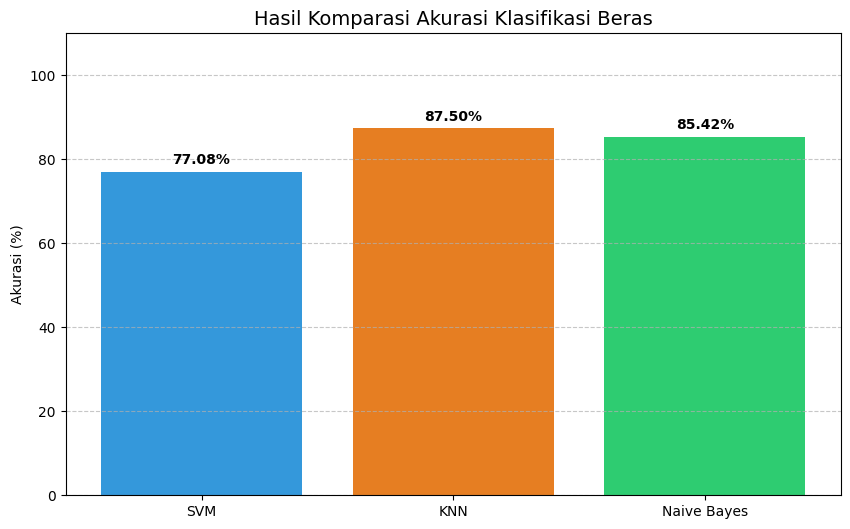

In [4]:
#@title 3. Pelatihan Model & Evaluasi (Optimized with Scaling)
from sklearn.preprocessing import StandardScaler

if len(X) > 0:
    # 1. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 2. Scalling Fitur (PENTING: Agar SVM tidak lambat)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Inisialisasi Model
    models = {
        "SVM": SVC(kernel='linear', random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Naive Bayes": GaussianNB()
    }

    results = {}
    print("Melatih model dengan data yang sudah di-scaling...")

    for name, model in models.items():
        # Gunakan data yang sudah di-scaled
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred) * 100
        results[name] = acc
        print(f"✅ Selesai: {name} ({acc:.2f}%)")

    # 4. Visualisasi
    plt.figure(figsize=(10, 6))
    warna = ['#3498db', '#e67e22', '#2ecc71']
    bars = plt.bar(results.keys(), results.values(), color=warna)

    plt.title('Hasil Komparasi Akurasi Klasifikasi Beras', fontsize=14)
    plt.ylabel('Akurasi (%)')
    plt.ylim(0, 110)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%',
                 ha='center', va='bottom', fontweight='bold')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Gagal: Data X kosong. Pastikan Bagian 2 berhasil mengumpulkan gambar.")

In [5]:
#@title 4. Klasifikasi (Training Model) - Optimized
#@markdown Melatih tiga algoritma berbeda dengan fitur Scaling agar proses cepat dan akurat.
from sklearn.preprocessing import StandardScaler

# --- PROSES SCALING (Wajib agar SVM tidak lambat) ---
print("Melakukan standarisasi fitur...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- TRAINING MODEL ---
print("Melatih Model SVM (Linear)...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("Melatih Model KNN (k=5)...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

print("Melatih Model Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

print("\n✅ Semua model berhasil dilatih dalam waktu singkat!")

Melakukan standarisasi fitur...
Melatih Model SVM (Linear)...
Melatih Model KNN (k=5)...
Melatih Model Naive Bayes...

✅ Semua model berhasil dilatih dalam waktu singkat!



HASIL KOMPARASI METODE SVM, KNN, DAN NAIVE BAYES
1. Akurasi SVM         : 77.08%
2. Akurasi KNN         : 87.50%
3. Akurasi Naive Bayes : 85.42%



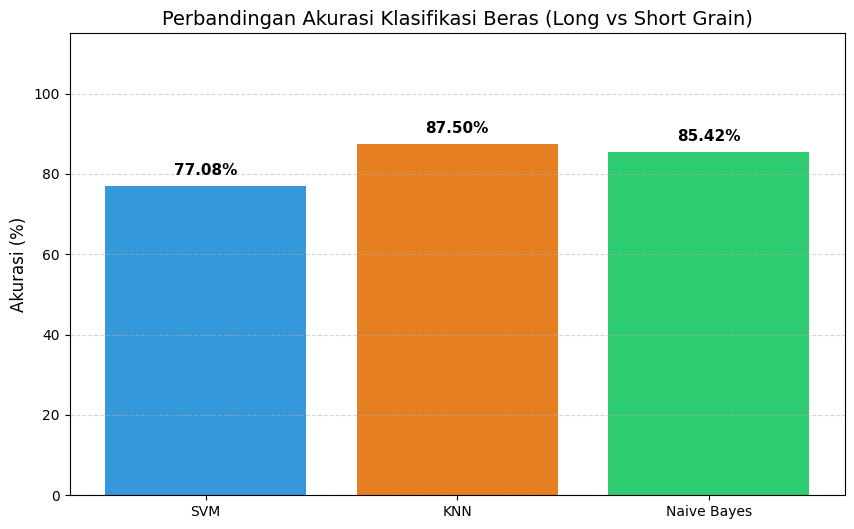

In [6]:
#@title 5. Output & Evaluasi (Updated)
#@markdown Menampilkan akurasi akhir dan visualisasi perbandingan performa antar metode menggunakan data yang telah di-scaling.

# --- 1. Prediksi Menggunakan Data Scaled ---
# Penting: Harus menggunakan X_test_scaled agar sinkron dengan model yang sudah dilatih
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_nb = nb_model.predict(X_test_scaled)

# --- 2. Hitung Akurasi ---
akurasi_svm = accuracy_score(y_test, y_pred_svm) * 100
akurasi_knn = accuracy_score(y_test, y_pred_knn) * 100
akurasi_nb = accuracy_score(y_test, y_pred_nb) * 100

print("\n" + "="*60)
print("HASIL KOMPARASI METODE SVM, KNN, DAN NAIVE BAYES")
print("="*60)
print(f"1. Akurasi SVM         : {akurasi_svm:.2f}%")
print(f"2. Akurasi KNN         : {akurasi_knn:.2f}%")
print(f"3. Akurasi Naive Bayes : {akurasi_nb:.2f}%\n")

# --- 3. Visualisasi ---
metode = ['SVM', 'KNN', 'Naive Bayes']
akurasi = [akurasi_svm, akurasi_knn, akurasi_nb]

plt.figure(figsize=(10, 6))
# Menggunakan palet warna yang modern
warna_bar = ['#3498db', '#e67e22', '#2ecc71']
bars = plt.bar(metode, akurasi, color=warna_bar)

# Labeling Grafik
plt.title('Perbandingan Akurasi Klasifikasi Beras (Long vs Short Grain)', fontsize=14)
plt.ylabel('Akurasi (%)', fontsize=12)
plt.ylim(0, 115) # Memberi ruang di atas bar untuk teks persentase

# Menambahkan angka akurasi di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()